In [2]:
#importing libraries and loading the datasets
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt
import os

# train_dir = "../datasets/crop_disease/Train"
# val_dir = "../datasets/crop_disease/Validation"

# img_size = (128,128)
# batch_size = 64

# train_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     train_dir,
#     image_size=img_size,
#     batch_size=batch_size
# )

# val_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     val_dir,
#     image_size=img_size,
#     batch_size=batch_size
# )




IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "../datasets/crop_disease/Train/"
val_dir = "../datasets/crop_disease/Validation/"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 15450 files belonging to 42 classes.
Found 3172 files belonging to 42 classes.
['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy Maize', 'Healthy Wheat', 'Healthy cotton', 'Leaf Curl', 'Leaf smut', 'Mosaic sugarcane', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'Tungro', 'Wheat Brown leaf Rust', 'Wheat Stem fly', 'Wheat aphid', 'Wheat black rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane', 'bacterial_blight in Cotton', 'bollrot on Cotton', 'bollworm on Cotton', 'cotton mealy bug', 'cotton whitefly', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'pink bollworm in cotton', 'red cotton bug', 'thirps on  cotton']


In [3]:
#checking the classes names
class_names = train_ds.class_names
print(class_names)

['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy Maize', 'Healthy Wheat', 'Healthy cotton', 'Leaf Curl', 'Leaf smut', 'Mosaic sugarcane', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'Tungro', 'Wheat Brown leaf Rust', 'Wheat Stem fly', 'Wheat aphid', 'Wheat black rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane', 'bacterial_blight in Cotton', 'bollrot on Cotton', 'bollworm on Cotton', 'cotton mealy bug', 'cotton whitefly', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'pink bollworm in cotton', 'red cotton bug', 'thirps on  cotton']


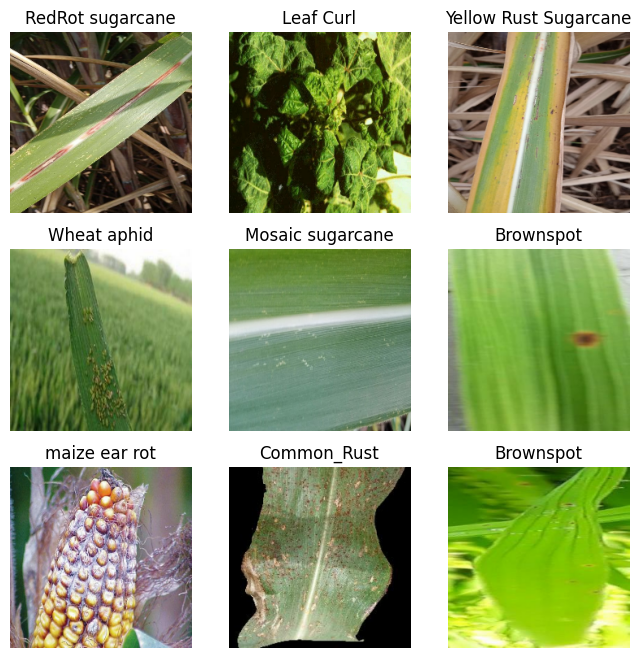

In [4]:
#visualization of datasets
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
#normalization of images
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y))

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
#Data Augmentation (important for accuracy)
# data_augmentation = keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1),
# ])


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [8]:
# building a model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs=base_model.input, outputs=outputs)

In [9]:
#compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [1]:
#train model
epochs = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

NameError: name 'model' is not defined

In [ ]:
#evaluate model
test_loss, test_acc = model.evaluate(val_ds)

print("Validation Accuracy:", test_acc)

In [23]:
# #Building CNN-Convulational Neural Network model
# model = keras.Sequential([

#     data_augmentation,

#     layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
#     layers.MaxPooling2D(),

#     layers.Conv2D(64,(3,3),activation="relu"),
#     layers.MaxPooling2D(),

#     layers.Conv2D(128,(3,3),activation="relu"),
#     layers.MaxPooling2D(),

#     layers.Flatten(),

#     layers.Dense(128,activation="relu"),
#     layers.Dropout(0.5),

#     layers.Dense(len(class_names),activation="softmax")
# ])



model = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(len(class_names),activation="softmax")
])

In [24]:
# #compiling the model
# model.compile(
#     optimizer="adam",
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )



model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
#checking the architecture
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
#Training the model
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.4399 - loss: 2.2832 - val_accuracy: 0.0076 - val_loss: 3.8743
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.5866 - loss: 1.5722 - val_accuracy: 0.0013 - val_loss: 3.7422
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 235s 971ms/step - accuracy: 0.6525 - loss: 1.2987 - val_accuracy: 0.0180 - val_loss: 9.2290
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.7041 - loss: 1.1137 - val_accuracy: 0.0867 - val_loss: 46.3180
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.7302 - loss: 1.0060 - val_accuracy: 0.0555 - val_loss: 62.9952
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7482 - loss: 0.9324 - val_accuracy: 0.0110 - val_loss: 45.7197
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 236s 975ms/step - accuracy: 0.7715 - loss: 0.8389 - val_accuracy: 0.0057 - val_loss: 76.3643
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.7865 - loss: 0.7808 

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# FIX: pass preprocess_input
model = load_model(
    "../ml_models/disease_detection/disease_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

#plot visualization of accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

d:\Smart_Agri_System\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


d:\Smart_Agri_System\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


NameError: name 'history' is not defined

In [7]:
#Evaluation of model
test_loss, test_acc = model.evaluate(val_ds)

print("Validation Accuracy:", test_acc)

NameError: name 'model' is not defined

In [ ]:
# #model.save("crop_disease_model.h5")

# import joblib

# joblib.dump(model, "../ml_models/disease_detection/disease_model.pkl")
# print("Model saved successfully!")

Model saved successfully!


In [ ]:
#again from scratching
#this has been trained in google colab
#importing libraries and setting path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt

import os
import shutil

# Paths
source_train = "/content/drive/MyDrive/crop_disease/Train"
source_val = "/content/drive/MyDrive/crop_disease/Validation"

# target_train = "/content/filtered_dataset/Train"
# target_val = "/content/filtered_dataset/Validation"

target_train = "/content/drive/MyDrive/filtered_dataset/Train"
target_val   = "/content/drive/MyDrive/filtered_dataset/Validation"

# Classes to select
selected_classes = [
    "Rice Blast",
    "Becterial Blight in Rice",
    "Brownspot",
    "Healthy Rice Leaf",
    "maize fall armyworm",
    "maize stem borer",
    "maize ear rot",
    "Healthy Maize",
    "Wheat Brown leaf Rust",
    "Wheat powdery mildew",
    "Healthy Wheat",
    "RedRot sugarcane",
    "Sugarcane Healthy",
    "Healthy cotton",
    "bollworm on Cotton"
]

# Function to copy dataset safely
def copy_dataset(source_dir, target_dir, classes):
    os.makedirs(target_dir, exist_ok=True)

    for cls in classes:
        src = os.path.join(source_dir, cls)
        dst = os.path.join(target_dir, cls)

        if os.path.exists(src):
            # Remove existing folder if exists
            if os.path.exists(dst):
                shutil.rmtree(dst)
            # Copy the folder
            shutil.copytree(src, dst)
            print(f"Copied {cls}")
        else:
            print(f"Warning: {cls} not found in {source_dir}")

# Copy Train and Validation
copy_dataset(source_train, target_train, selected_classes)
copy_dataset(source_val, target_val, selected_classes)

In [ ]:
# Make sure this points to the correct source folder with renamed name
source_val = "/content/drive/MyDrive/crop_disease/Validation"
target_val = "/content/drive/MyDrive/filtered_dataset/Validation"

# Re-run copy for Validation only
copy_dataset(source_val, target_val, selected_classes)

In [ ]:
# Check number of class folders
print("Train class folders:", len(os.listdir(target_train)))  # Should be 15

# Check total number of images
total_images = sum([len(os.listdir(os.path.join(target_train, cls))) for cls in os.listdir(target_train)])
print("Total train images:", total_images)

In [ ]:
# Check total number of images
print("Validation folders:", len(os.listdir(target_val)))

# Check total number of images
total_images = sum([len(os.listdir(os.path.join(target_val, cls))) for cls in os.listdir(target_val)])
print("Total target images:", total_images)

In [ ]:
#checking train and validaition files 
for cls in selected_classes:
    train_count = len(os.listdir(os.path.join(target_train, cls)))
    val_count = len(os.listdir(os.path.join(target_val, cls))) if os.path.exists(os.path.join(target_val, cls)) else 0
    print(f"{cls}: Train={train_count}, Validation={val_count}")

In [ ]:
for cls in selected_classes:
    train_count = len(os.listdir(os.path.join(target_train, cls)))
    val_count = len(os.listdir(os.path.join(target_val, cls))) if os.path.exists(os.path.join(target_val, cls)) else 0
    print(f"{cls}: Train={train_count}, Validation={val_count}")

In [ ]:
train_dir = "/content/drive/MyDrive/filtered_dataset/Train"
val_dir = "/content/drive/MyDrive/filtered_dataset/Validation"

In [ ]:
print(os.listdir(train_dir))

In [ ]:
#Loading the datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32
)

#print(class_names)

In [ ]:
#checking the classes names
class_names = train_ds.class_names
print(class_names)

In [ ]:
#prefetching dataset
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
#data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [ ]:
#load retained data
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze weights

In [ ]:
# #Building model
# model = keras.Sequential([
#     data_augmentation,

#     tf.keras.applications.mobilenet_v2.preprocess_input,

#     base_model,

#     layers.GlobalAveragePooling2D(),

#     layers.BatchNormalization(),

#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),

#     layers.Dense(len(class_names), activation='softmax')
# ])

model = keras.Sequential([
    data_augmentation,

    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
#train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

In [ ]:
#Evaluation of model
test_loss, test_acc = model.evaluate(val_ds)

print("Validation Accuracy:", test_acc)

In [ ]:
#checking the architecture
model.summary()

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

In [ ]:
#save model
model.save('/content/drive/MyDrive/disease_model.h5')


In [3]:
#Testing the prediction

# import joblib
# price_model = joblib.load("../ml_models/disease_detection/disease_model.h5")
# import tensorflow as tf
# from tensorflow.keras.models import load_model


from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("../ml_models/disease_detection/disease_model.h5")  # ✅ Correct

img = image.load_img("../datasets/crop_disease/test3.jpg", target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array/255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

TypeError: Could not locate function 'preprocess_input'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'preprocess_input', 'registered_name': 'function'}

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [29]:
import os

print(len(os.listdir("../datasets/crop_disease/Train/")))
print(len(os.listdir("../datasets/crop_disease/Validation/")))

42
42


In [4]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained Keras model
model = load_model("../ml_models/disease_detection/disease_model.h5")

# Load test image
img = image.load_img("../datasets/crop_disease/test3.jpg", target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0                  # Normalize

# Make prediction
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Predicted Disease: {predicted_class} (Confidence: {confidence*100:.2f}%)")

TypeError: Could not locate function 'preprocess_input'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'preprocess_input', 'registered_name': 'function'}

In [52]:
#prediction using sample image data

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# FIX: pass preprocess_input
model = load_model(
    "../ml_models/disease_detection/disease_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

# Load image
img = image.load_img("../datasets/crop_disease/redrot (398).jpeg", target_size=(224,224))
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# IMPORTANT: DO NOT normalize manually (Lambda already does it)
# img_array = img_array / 255.0  (REMOVE THIS)

# Predict
prediction = model.predict(img_array)

predicted_class_index = np.argmax(prediction)

print("Class index:", predicted_class_index)

d:\Smart_Agri_System\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Class index: 6


In [58]:

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

# FIX: pass preprocess_input
model = load_model(
    "../ml_models/disease_detection/disease_model.h5",
    custom_objects={"preprocess_input": preprocess_input}
)

img = image.load_img("../datasets/crop_disease/bact220.jpg", target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

# ✅ IMPORTANT FIX
#img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

predicted_class_index = np.argmax(prediction)

print("Class index:", predicted_class_index)
# print("Predicted:", class_names[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Class index: 14


In [59]:
class_names = [
    'Becterial Blight in Rice', 
    'Brownspot', 
    'Healthy Maize', 
    'Healthy Rice Leaf', 
    'Healthy Wheat', 
    'Healthy cotton', 
    'RedRot sugarcane',
    'Rice Blast', 
    'Sugarcane Healthy', 
    'Wheat Brown leaf Rust', 
    'Wheat powdery mildew', 
    'bollworm on Cotton', 
    'maize ear rot', 
    'maize fall armyworm', 
    'maize stem borer'
]

print("Predicted:", class_names[predicted_class_index])


Predicted: maize stem borer


In [31]:
print(prediction)

[[2.6183823e-12 4.6850844e-12 2.3471136e-14 7.3892905e-13 1.7214376e-11
  1.6944543e-12 6.4800665e-11 4.3865124e-12 3.8538488e-14 5.4396380e-11
  4.5186888e-13 5.3252056e-11 9.9999821e-01 4.0109111e-07 1.4616351e-06]]


In [32]:
for i, prob in enumerate(prediction[0]):
    print(i, class_names[i], prob)

0 Rice Blast 2.6183823e-12
1 Becterial Blight in Rice 4.6850844e-12
2 Brownspot 2.3471136e-14
3 Healthy Rice Leaf 7.3892905e-13
4 maize fall armyworm 1.7214376e-11
5 maize stem borer 1.6944543e-12
6 maize ear rot 6.4800665e-11
7 Healthy Maize 4.3865124e-12
8 Wheat Brown leaf Rust 3.8538488e-14
9 Wheat powdery mildew 5.439638e-11
10 Healthy Wheat 4.5186888e-13
11 RedRot sugarcane 5.3252056e-11
12 Sugarcane Healthy 0.9999982
13 Healthy cotton 4.010911e-07
14 bollworm on Cotton 1.4616351e-06
